# simple model 

In [122]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [2]:
df = pd.read_csv(r"C:\DataScience\Deep Learning\Optimizers\diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# correlation btw them

df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [5]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [8]:
model = Sequential()

model.add(Dense(32,activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\DataScience\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(X_train_scaled, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6701 - loss: 0.6535 - val_accuracy: 0.6585 - val_loss: 0.6530
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7149 - loss: 0.6162 - val_accuracy: 0.6585 - val_loss: 0.6252
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7189 - loss: 0.5880 - val_accuracy: 0.6911 - val_loss: 0.5988
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7332 - loss: 0.5653 - val_accuracy: 0.6992 - val_loss: 0.5787
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7475 - loss: 0.5466 - val_accuracy: 0.7236 - val_loss: 0.5638
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7576 - loss: 0.5317 - val_accuracy: 0.7480 - val_loss: 0.5502
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7556 - loss: 0.5194 - val_accuracy: 0.7480 - val_loss: 0.5395
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7637 - loss: 0.5083 - val_accuracy: 0.7398 - 

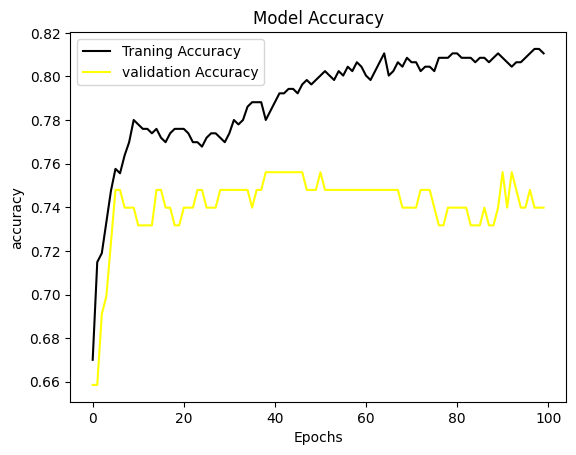

In [10]:
plt.plot(history.history['accuracy'],c='black', label='Traning Accuracy')
plt.plot(history.history['val_accuracy'],c='yellow', label='validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Automate Parameter using keras tuner

* 1. how to select appropriate optimizer
  2. no. of nodes in a layer
  3. how to select no. of layers
  4. All in one model 

In [11]:
import keras_tuner as kt

# optimizer

In [52]:
# def build_model(hp):
#     model = Sequential()
#     model.add(Dense(32, activation='relu', input_shape=(X_test_scaled.shape[1],)))
#     model.add(Dense(1, activation='sigmoid'))

#     optimizer = hp.Choice('optimizer',['adam', 'sgd', 'rmsprop', 'adadelta'])
    
#     model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
#     return model

In [48]:
# tuner = kt.RandomSearch(build_model,
#                         objective='val_accuracy',
#                         max_trials=6)

In [31]:
tuner.search(X_train_scaled, y_train, epochs=10, validation_data=(X_test_scaled,y_test))

In [28]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [33]:
model = tuner.get_best_models(num_models=1)[0]

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.fit(X_train_scaled,y_train, batch_size=32, epochs=100, initial_epoch=21, validation_data=(X_test_scaled, y_test))

Epoch 22/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7671 - loss: 0.4671 - val_accuracy: 0.7403 - val_loss: 0.5120
Epoch 23/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7704 - loss: 0.4611 - val_accuracy: 0.7597 - val_loss: 0.5109
Epoch 24/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.4580 - val_accuracy: 0.7792 - val_loss: 0.5109
Epoch 25/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.4550 - val_accuracy: 0.7597 - val_loss: 0.5105
Epoch 26/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7801 - loss: 0.4525 - val_accuracy: 0.7532 - val_loss: 0.5101
Epoch 27/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7785 - loss: 0.4501 - val_accuracy: 0.7468 - val_loss: 0.5098
Epoch 28/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7801 - loss: 0.4478 - val_accuracy: 0.7403 - val_loss: 0.5110
Epoch 29/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7850 - loss: 0.4456 - val_accuracy: 0

# number of Nurons

In [96]:
def build_model(hp):

    model = Sequential()
    
    # unit = hp.Choice('units',[8,16,32,64,128,256])
    unit = hp.Int('units', min_value=8, max_value=128,step=8)

    model.add(Dense(units=unit, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = hp.Choice('optimizer',['adam', 'sgd', 'rmsprop', 'adadelta'])
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [97]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=7,
                        directory='tuner_results',
                        project_name='units_optimizer_tuning',
                        overwrite=True)

c:\DataScience\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
tuner.search(X_train_scaled,y_train, epochs=10, validation_data=(X_test_scaled, y_test))

Trial 7 Complete [00h 00m 03s]
val_accuracy: 0.33766233921051025

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 18s


In [99]:
tuner.get_best_hyperparameters()[0].values

{'units': 128, 'optimizer': 'adam'}

In [100]:
model = tuner.get_best_models(num_models=1)[0]

c:\DataScience\venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [101]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
history = model.fit(X_train_scaled, y_train, epochs=100, initial_epoch=8, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 9/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7655 - loss: 0.5005 - val_accuracy: 0.7857 - val_loss: 0.5030
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7736 - loss: 0.4794 - val_accuracy: 0.7727 - val_loss: 0.4957
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7736 - loss: 0.4662 - val_accuracy: 0.7662 - val_loss: 0.4950
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7736 - loss: 0.4605 - val_accuracy: 0.7662 - val_loss: 0.5001
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.4543 - val_accuracy: 0.7532 - val_loss: 0.5017
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.4504 - val_accuracy: 0.7532 - val_loss: 0.5055
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7866 - loss: 0.4458 - val_accuracy: 0.7532 - val_loss: 0.5073
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.4433 - val_accuracy: 0.7662 - val_l

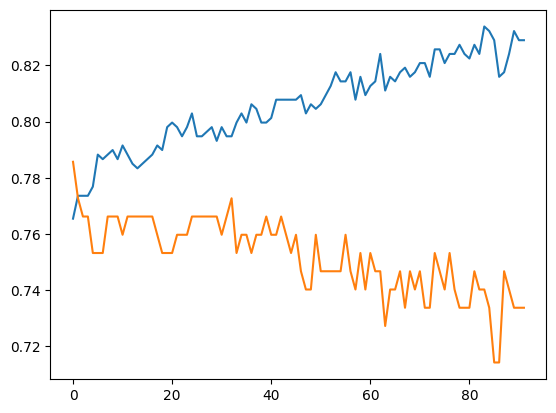

In [103]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

# number of layers

In [113]:
def build_layer_model(hp):

    model = Sequential()

    model.add(Dense(72, activation='relu', input_shape=(X_train_scaled.shape[1],)))

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):

        model.add(Dense(72, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [114]:
tuner = kt.RandomSearch(build_layer_model,
                        objective='val_accuracy',
                        max_trials=3,
                        directory='tuner_results',
                        project_name='layers_tuning',
                        overwrite=True)


c:\DataScience\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [115]:
tuner.search(X_train_scaled,y_train,epochs=10, validation_data=(X_test_scaled,y_test))

Trial 3 Complete [00h 00m 05s]
val_accuracy: 0.7662337422370911

Best val_accuracy So Far: 0.7727272510528564
Total elapsed time: 00h 00m 19s


In [116]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 6}

In [117]:
model = tuner.get_best_models(num_models=1)[0]

c:\DataScience\venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [118]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 72)             │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 72)             │         5,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,257 (126.00 KB)

 Trainable params: 32,257 (126.00 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
history = model.fit(X_train_scaled,y_train, epochs=100, initial_epoch=4, validation_data=(X_test_scaled,y_test), batch_size=32)

Epoch 5/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7769 - loss: 0.4525 - val_accuracy: 0.6818 - val_loss: 0.5875
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7932 - loss: 0.4335 - val_accuracy: 0.7273 - val_loss: 0.5311
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7980 - loss: 0.4213 - val_accuracy: 0.7078 - val_loss: 0.5573
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7948 - loss: 0.4149 - val_accuracy: 0.7468 - val_loss: 0.5547
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8208 - loss: 0.3988 - val_accuracy: 0.6883 - val_loss: 0.6408
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8176 - loss: 0.3940 - val_accuracy: 0.7403 - val_loss: 0.5319
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8160 - loss: 0.3778 - val_accuracy: 0.6948 - val_loss: 0.5988
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8257 - loss: 0.3837 - val_accuracy: 0.7662 - val_loss:

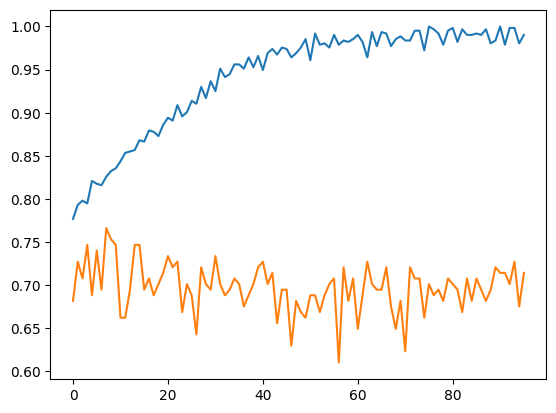

In [120]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

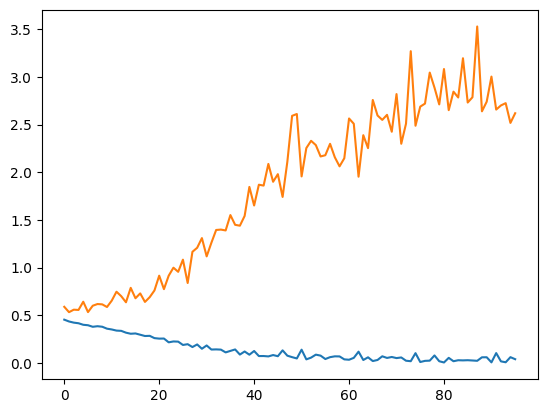

In [121]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# ALL in One

In [125]:
def build_model(hp):
    model = Sequential()

    counter = 0

    for i in range(hp.Int('layers', min_value=1, max_value=10)):

        if counter == 0:
            model.add(Dense(
                hp.Int('nodes'+str(i), min_value=8, max_value=128),
                activation=hp.Choice('active'+str(i), ['relu','tanh','sigmoid','elu','prelu'])
            ))
            model.add(Dropout(hp.Choice('Droup'+str(i), [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        else:
            model.add(Dense(
                hp.Int('nodes'+str(i), min_value=8, max_value=128),
                activation=hp.Choice('active'+str(i), ['relu','tanh','sigmoid','elu','prelu'])
            ))
            model.add(Dropout(hp.Choice('Droup'+str(i), [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))

    model.add(Dense(1,activation='sigmoid'))

    model.compile(optimizer=hp.Choice('optimizer', ['adam','rmsprop','sgd','nadam','adadelta']),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                  )
    return model
          

In [126]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=4,
                        directory='final_result',
                        project_name='efficient_result',
                        overwrite=True)

In [127]:
tuner.search(X_train_scaled,y_train,epochs=5,validation_data=(X_test_scaled,y_test))

Trial 4 Complete [00h 00m 08s]
val_accuracy: 0.6428571343421936

Best val_accuracy So Far: 0.7662337422370911
Total elapsed time: 00h 00m 26s


In [128]:
tuner.get_best_hyperparameters()[0].values

{'layers': 1,
 'nodes0': 50,
 'active0': 'tanh',
 'Droup0': 0.3,
 'optimizer': 'sgd',
 'nodes1': 119,
 'active1': 'sigmoid',
 'Droup1': 0.6,
 'nodes2': 43,
 'active2': 'relu',
 'Droup2': 0.5,
 'nodes3': 111,
 'active3': 'prelu',
 'Droup3': 0.1,
 'nodes4': 35,
 'active4': 'tanh',
 'Droup4': 0.6}

In [129]:
model = tuner.get_best_models(num_models=1)[0]

In [130]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
history = model.fit(X_train_scaled,y_train,epochs=200,initial_epoch=6, validation_data=(X_test_scaled,y_test))

Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7215 - loss: 0.5562 - val_accuracy: 0.7597 - val_loss: 0.5257
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7166 - loss: 0.5459 - val_accuracy: 0.7532 - val_loss: 0.5137
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7410 - loss: 0.5335 - val_accuracy: 0.7597 - val_loss: 0.5055
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7524 - loss: 0.5273 - val_accuracy: 0.7597 - val_loss: 0.4979
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7492 - loss: 0.5089 - val_accuracy: 0.7597 - val_loss: 0.4933
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7590 - loss: 0.4984 - val_accuracy: 0.7662 - val_loss: 0.4895
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7508 - loss: 0.5197 - val_accuracy: 0.7727 - val_loss: 0.4864
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7378 - loss: 0.5140 - val_accurac

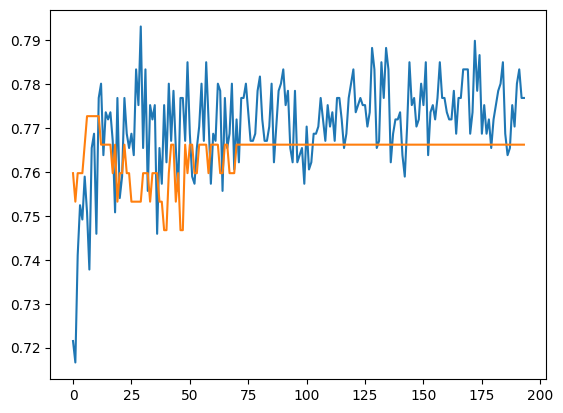

In [133]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])